In [1]:
# === Imports and settings ===
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import gaussian_kde

# Configure matplotlib for consistent style
plt.rcParams.update({
    "font.size": 18,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"]
})
dpi_num = 100

In [2]:
# === Data directories ===
dirs = {
    "2q": {
        "Brydges": r"..\analytical_solution\results\2q",
        "stella":    r"..\models\outputs\2q\outputs_attention",
        "MLP":    r"..\models\outputs\2q\outputs_MLP"
    },
    "4q": {
        "Brydges": r"..\analytical_solution\results\4q",
        "stella":    r"..\models\outputs\4q\outputs_attention",
        "MLP":    r"..\models\outputs\4q\outputs_MLP"
    }
}

#Consistent colors and markers
global colors
global markers

colors = {"MLP": "teal", "Brydges": "goldenrod", "stella": "hotpink"}
markers = {"MLP": "^", "Brydges": "s", "stella": "d"}

### Distribution of entropies

In [3]:
def page_entropy_mean(num_qubits):
    m = 2
    n = 2**((num_qubits - 1) // 2)  # equal bipartition

    sol = sum(1/k for k in range(m + 1, m*n + 1))
    sol -= (n - 1) / (2 * m)

    return sol / np.log(2)

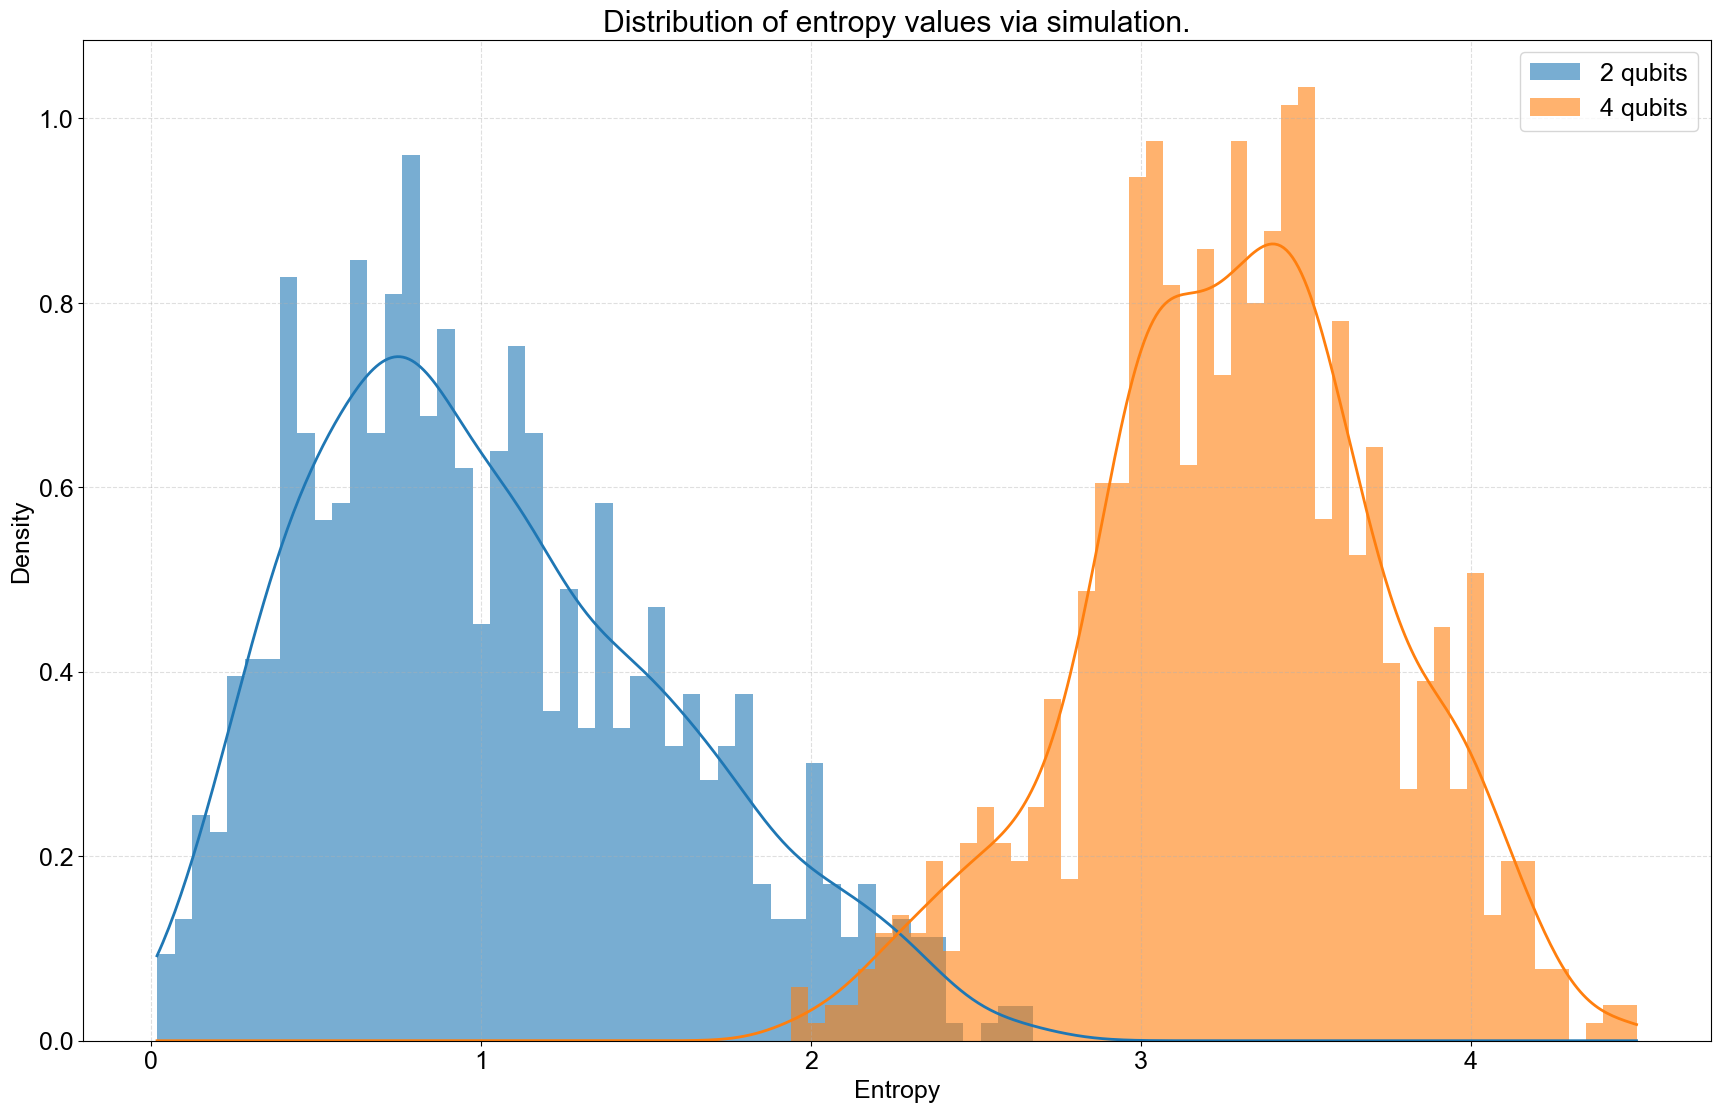

In [4]:
Nm_2 = 200; Nu_2 = 100
Nm_4 = 200; Nu_4 = 500

true_algo = np.loadtxt(os.path.join(dirs["2q"]["Brydges"], f"{Nm_2}shot_{Nu_2}unitary_true.txt"))
true_mlp = np.loadtxt(os.path.join(dirs["2q"]["MLP"], f"{Nm_2}shot_{Nu_2}unitary_true.txt"))
true_stella = np.loadtxt(os.path.join(dirs["2q"]["stella"], f"{Nm_2}shot_{Nu_2}unitary_true.txt"))

entropies_2 = true_algo + true_mlp + true_stella

true_algo = np.loadtxt(os.path.join(dirs["4q"]["Brydges"], f"{Nm_4}shot_{Nu_4}unitary_true.txt"))
true_mlp = np.loadtxt(os.path.join(dirs["4q"]["MLP"], f"{Nm_4}shot_{Nu_4}unitary_true.txt"))
true_stella = np.loadtxt(os.path.join(dirs["4q"]["stella"], f"{Nm_4}shot_{Nu_4}unitary_true.txt"))

entropies_4 = true_algo + true_mlp + true_stella

color1 = 'tab:blue'
color2 = 'tab:orange'

fig, ax = plt.subplots(1, 1, figsize=(21, 13), dpi=dpi_num)

plt.hist(entropies_2, bins=50, density=True, alpha=0.6, label='2 qubits', color=color1)
plt.hist(entropies_4, bins=50, density=True, alpha=0.6, label='4 qubits', color=color2)

x = np.linspace(min(entropies_2.min(), entropies_4.min()), max(entropies_2.max(), entropies_4.max()), 500)

kde1 = gaussian_kde(entropies_2)
kde2 = gaussian_kde(entropies_4)

plt.plot(x, kde1(x), linewidth=2, color = color1)
plt.plot(x, kde2(x), linewidth=2, color = color2)

# plt.axvline(page_entropy_mean(2), color=color1, linestyle='--', label="Page Entropy 2 qubits")
# plt.axvline(page_entropy_mean(4), color=color2, linestyle='--', label="Page Entropy 4 qubits")

# Labels and legend
plt.xlabel('Entropy')
plt.ylabel('Density')
plt.legend()
ax.grid(True, linestyle="--", alpha=0.4)

plt.title("Distribution of entropy values via simulation.")

plt.savefig(f"page_curve.pdf", format="pdf", bbox_inches="tight")

plt.show()

### Loss Plots of the Model(s)

In [5]:
def load_losses(base_dir):
    """Load training and evaluation losses from a directory."""
    train = np.loadtxt(os.path.join(base_dir, "training_loss"))
    eval_ = np.loadtxt(os.path.join(base_dir, "eval_loss"))
    return train, eval_


# === Load training/eval loss data ===
losses_2q = {
    "MLP":    load_losses(dirs["2q"]["MLP"]),
    "stella":    load_losses(dirs["2q"]["stella"]),
}
losses_4q = {
    "MLP":    load_losses(dirs["4q"]["MLP"]),
    "stella":    load_losses(dirs["4q"]["stella"]),
}

# Epoch axis (scaled by factor of 10 like in your original script)
epochs_2q = np.arange(1, len(losses_2q["MLP"][0]) + 1) * 10
epochs_4q = np.arange(1, len(losses_4q["stella"][0]) + 1) * 10


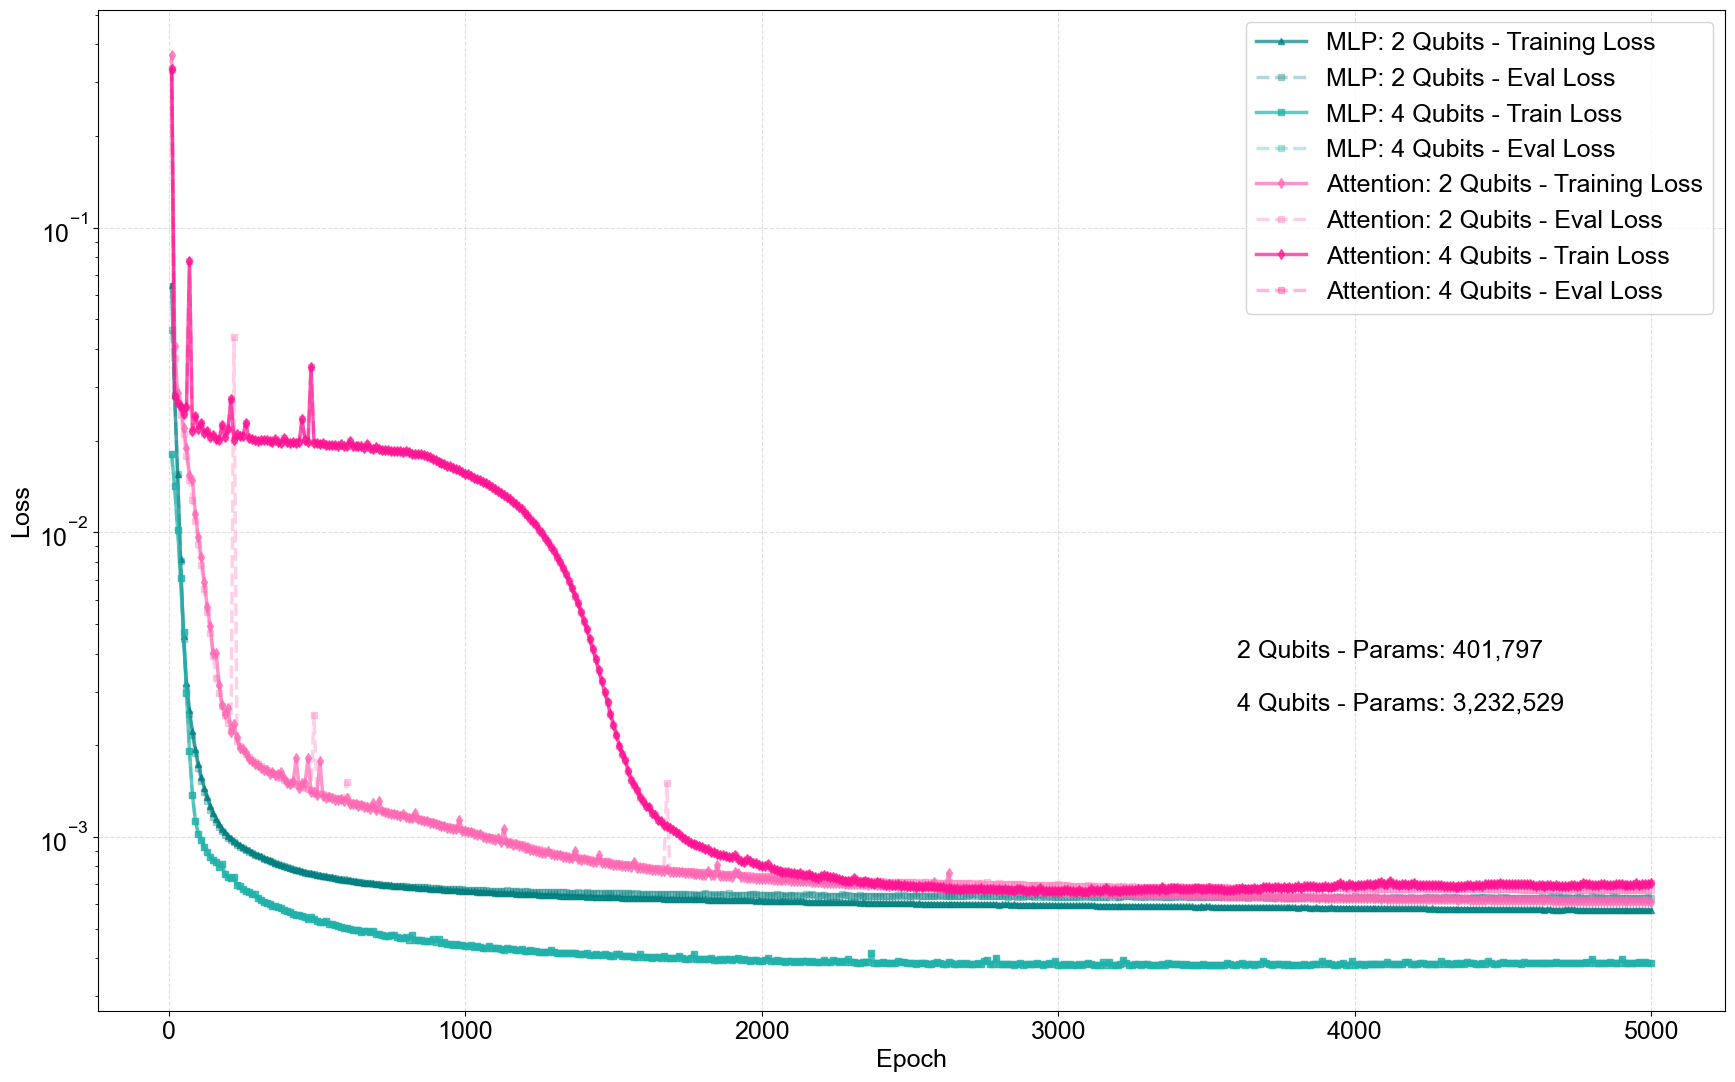

In [6]:
# === Plot training and evaluation loss ===
fig, ax = plt.subplots(1, 1, figsize=(21, 13), dpi=dpi_num)

styles = {"eval": "dashed", "train": "solid"}

ax.plot(epochs_2q, losses_2q["MLP"][0], label=f"MLP: 2 Qubits - Training Loss", color=colors["MLP"], linestyle=styles["train"], linewidth=2.5, marker=markers["MLP"], markersize=5, alpha=0.7)
ax.plot(epochs_2q, losses_2q["MLP"][1], label=f"MLP: 2 Qubits - Eval Loss", color=colors["MLP"], linestyle=styles["eval"], linewidth=2.5, marker="s", markersize=5, alpha=0.3)
ax.plot(epochs_2q, losses_4q["MLP"][1], label=f"MLP: 4 Qubits - Train Loss", color="lightseagreen", linestyle=styles["train"], linewidth=2.5, marker=markers["Brydges"], markersize=5, alpha=0.7)
ax.plot(epochs_2q, losses_4q["MLP"][1], label=f"MLP: 4 Qubits - Eval Loss", color="lightseagreen", linestyle=styles["eval"], linewidth=2.5, marker="s", markersize=5, alpha=0.3)

ax.plot(epochs_2q, losses_2q["stella"][0], label=f"Attention: 2 Qubits - Training Loss", color=colors["stella"], linestyle=styles["train"], linewidth=2.5, marker=markers["stella"], markersize=5, alpha=0.7)
ax.plot(epochs_2q, losses_2q["stella"][1], label=f"Attention: 2 Qubits - Eval Loss", color=colors["stella"], linestyle=styles["eval"], linewidth=2.5, marker="s", markersize=5, alpha=0.3)
ax.plot(epochs_4q, losses_4q["stella"][1], label=f"Attention: 4 Qubits - Train Loss", color="deeppink", linestyle=styles["train"], linewidth=2.5, marker=markers["stella"], markersize=5, alpha=0.7)
ax.plot(epochs_4q, losses_4q["stella"][1], label=f"Attention: 4 Qubits - Eval Loss", color="deeppink", linestyle=styles["eval"], linewidth=2.5, marker="s", markersize=5, alpha=0.3)

params_2q = "401,797"; params_4q =  "3,232,529"

ax.text(0.7, 0.3, f'2 Qubits - Params: {params_2q} \n\n4 Qubits - Params: {params_4q}', 
        transform=ax.transAxes, color="black")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="best")

plt.savefig(f"loss_plot.pdf", format="pdf", bbox_inches="tight")

plt.show()

### Model convergence with NuNm

In [7]:
# === Parameters for scatter plots ===
Nm_list_2 = np.logspace(np.log10(1), np.log10(200), num=10, dtype=int)
Nu_list_2 = np.linspace(1, 100, num=10, dtype=int)

Nm_list_4 = np.logspace(np.log10(1), np.log10(200), num=10, dtype=int)
Nu_list_4 = np.linspace(1, 500, num=10, dtype=int)

# Pick 3 representative Nm and Nu values
selected_Nm_2q = [Nm_list_2[0], Nm_list_2[5], Nm_list_2[9]]
selected_Nu_2q = [Nu_list_2[0], Nu_list_2[5], Nu_list_2[9]]

selected_Nm_4q = [Nm_list_4[0], Nm_list_4[5], Nm_list_4[9]]
selected_Nu_4q = [Nu_list_4[0], Nu_list_4[5], Nu_list_4[9]]

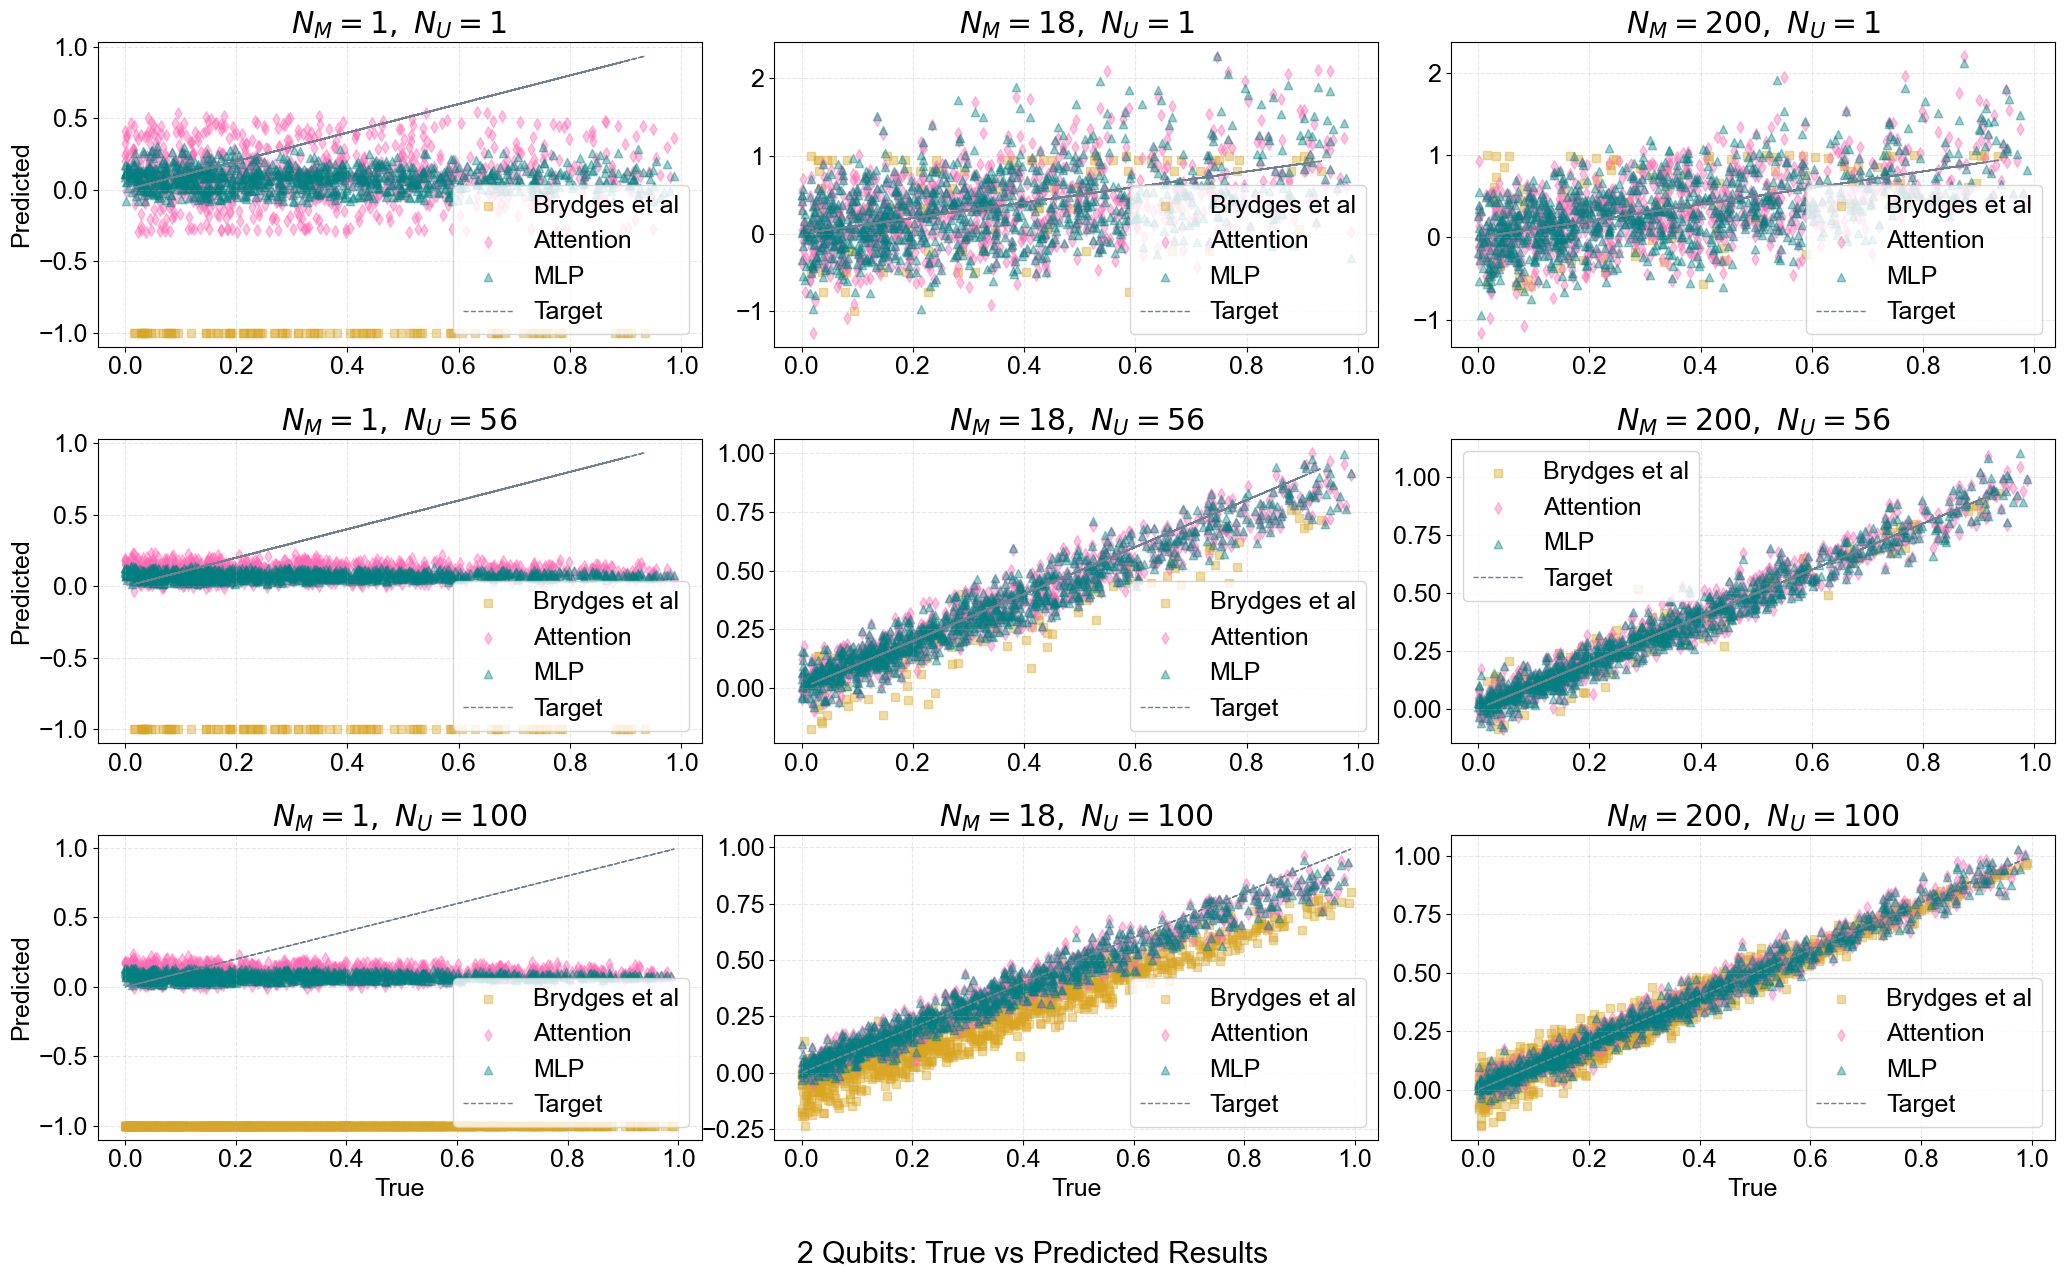

In [8]:
# === Create scatter plot grid ===
fig, axes = plt.subplots(3, 3, figsize=(21, 13), dpi=dpi_num, 
                         sharex=False, sharey=False)
axes = axes.reshape(3, 3)  # make indexing consistent

# 2q results (left block)
for i, Nu in enumerate(selected_Nu_2q):
    for j, Nm in enumerate(selected_Nm_2q):

        ax = axes[i, j]

        #Load data (algorithm)
        pred_path_algo = os.path.join(dirs["2q"]["Brydges"], f"{Nm}shot_{Nu}unitary_predicted.txt")
        true_path_algo = os.path.join(dirs["2q"]["Brydges"], f"{Nm}shot_{Nu}unitary_true.txt")

        pred_algo, true_algo = np.loadtxt(pred_path_algo), np.loadtxt(true_path_algo)
        ax.scatter(true_algo, pred_algo, label="Brydges et al", color=colors["Brydges"], marker=markers["Brydges"], alpha=0.4)

        #Load data (model(s))
        pred_path_stella = os.path.join(dirs["2q"]["stella"], f"{Nm}shot_{Nu}unitary_predicted.txt")
        true_path_stella = os.path.join(dirs["2q"]["stella"], f"{Nm}shot_{Nu}unitary_true.txt")

        pred_stella, true_stella = np.loadtxt(pred_path_stella), np.loadtxt(true_path_stella)
        ax.scatter(true_stella, pred_stella, label="Attention", color=colors["stella"], marker=markers["stella"], alpha=0.4)
        
        #Load data (model(s))
        pred_path_mlp = os.path.join(dirs["2q"]["MLP"], f"{Nm}shot_{Nu}unitary_predicted.txt")
        true_path_mlp = os.path.join(dirs["2q"]["MLP"], f"{Nm}shot_{Nu}unitary_true.txt")

        pred_mlp, true_mlp = np.loadtxt(pred_path_mlp), np.loadtxt(true_path_mlp)
        ax.scatter(true_mlp, pred_mlp, label="MLP", color=colors["MLP"], marker=markers["MLP"], alpha=0.4)

        ax.plot(true_algo, true_algo, "--", color="slategray", lw=1, label="Target")
        
        ax.set_title(rf"$N_M={Nm},\ N_U={Nu}$")
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.legend(loc="best") 

        if i == 2: ax.set_xlabel("True")
        if j == 0: ax.set_ylabel("Predicted")

plt.suptitle('2 Qubits: True vs Predicted Results', y = -0.01)
plt.tight_layout()
plt.savefig(f"nunm_2qubits.pdf", format="pdf", bbox_inches="tight")
plt.show()

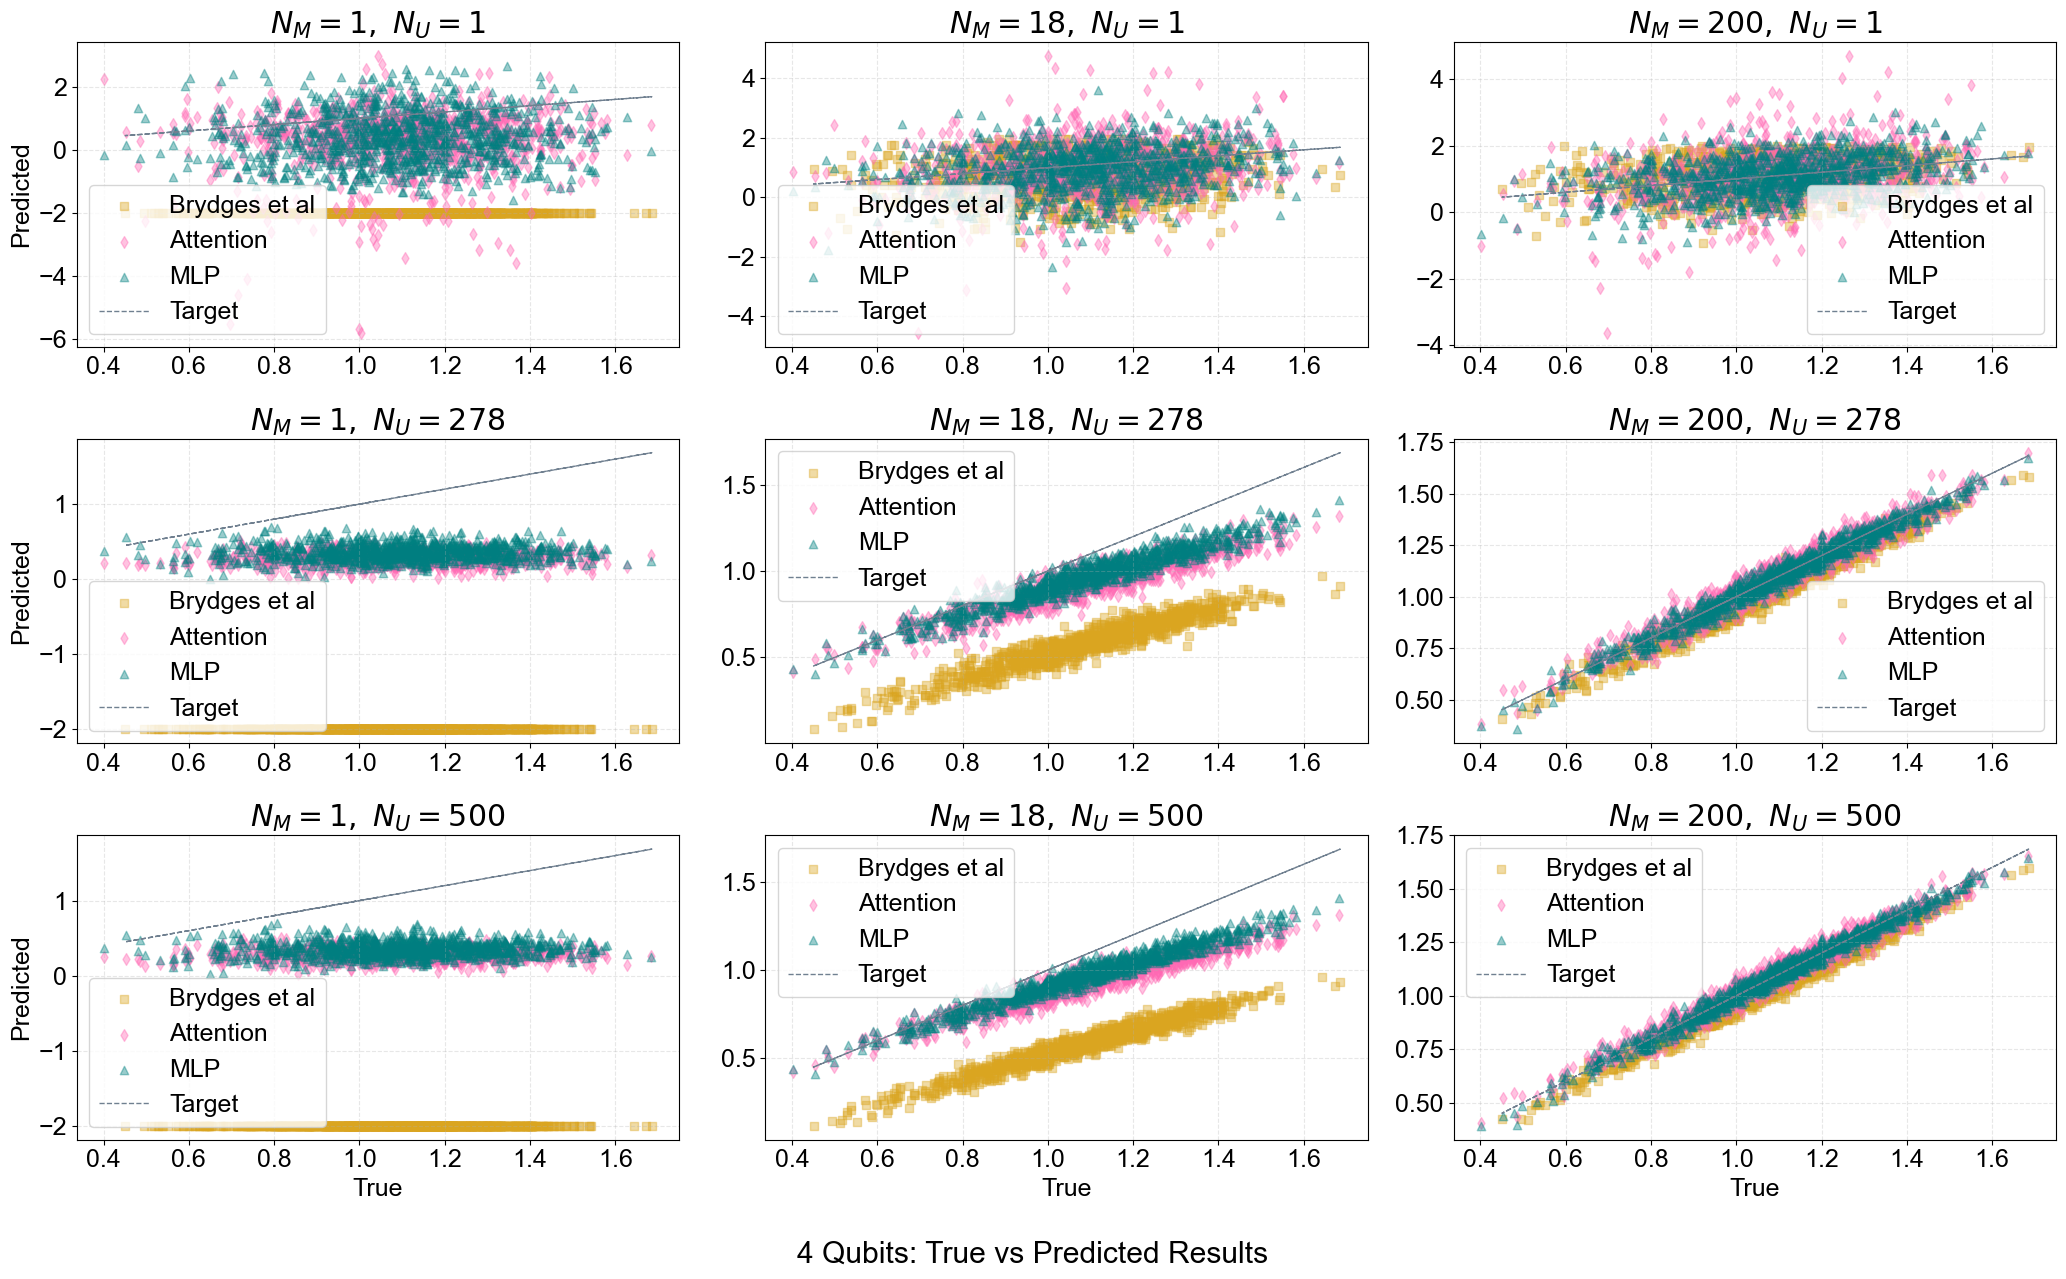

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(21, 13), dpi=dpi_num, 
                         sharex=False, sharey=False)
axes = axes.reshape(3, 3)  # make indexing consistent

# 4q results (right block)
for i, Nu in enumerate(selected_Nu_4q):
    for j, Nm in enumerate(selected_Nm_4q):
        ax = axes[i, j]  # shift to right block

        #Load data (algorithm)
        pred_path_algo = os.path.join(dirs["4q"]["Brydges"], f"{Nm}shot_{Nu}unitary_predicted.txt")
        true_path_algo = os.path.join(dirs["4q"]["Brydges"], f"{Nm}shot_{Nu}unitary_true.txt")

        pred_algo, true_algo = np.loadtxt(pred_path_algo), np.loadtxt(true_path_algo)
        ax.scatter(true_algo, pred_algo, label="Brydges et al", color=colors["Brydges"], marker=markers["Brydges"], alpha=0.4)

        #Load data (model(s))
        pred_path_stella = os.path.join(dirs["4q"]["stella"], f"{Nm}shot_{Nu}unitary_predicted.txt")
        true_path_stella = os.path.join(dirs["4q"]["stella"], f"{Nm}shot_{Nu}unitary_true.txt")

        pred_stella, true_stella = np.loadtxt(pred_path_stella), np.loadtxt(true_path_stella)
        ax.scatter(true_stella, pred_stella, label="Attention", color=colors["stella"], marker=markers["stella"], alpha=0.4)
        
        #Load data (model(s))
        pred_path_mlp = os.path.join(dirs["4q"]["MLP"], f"{Nm}shot_{Nu}unitary_predicted.txt")
        true_path_mlp = os.path.join(dirs["4q"]["MLP"], f"{Nm}shot_{Nu}unitary_true.txt")

        pred_mlp, true_mlp = np.loadtxt(pred_path_mlp), np.loadtxt(true_path_mlp)
        ax.scatter(true_mlp, pred_mlp, label="MLP", color=colors["MLP"], marker=markers["MLP"], alpha=0.4)

        ax.plot(true_algo, true_algo, "--", color="slategray", lw=1, label="Target")
        
        ax.set_title(rf"$N_M={Nm},\ N_U={Nu}$")
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.legend(loc="best") 

        if i == 2: ax.set_xlabel("True")
        if j == 0: ax.set_ylabel("Predicted")

plt.suptitle('4 Qubits: True vs Predicted Results', y = -0.01)
plt.tight_layout()
plt.savefig(f"nunm_4qubits.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Error convergence with models and algos

In [10]:
error_thresholds = {
    '2q': 0.04,
    '4q': 0.06
}

unc_threshold = {
    '2q': 0.04,
    '4q': 0.1
}

In [11]:
mlp_all_loss_2q = np.loadtxt(os.path.join(dirs["2q"]["MLP"], 'testing_loss.txt'))
mlp_all_loss_4q = np.loadtxt(os.path.join(dirs["4q"]["MLP"], 'testing_loss.txt'))

stella_all_loss_2q = np.loadtxt(os.path.join(dirs["2q"]["stella"], 'testing_loss.txt'))
stella_all_loss_4q = np.loadtxt(os.path.join(dirs["4q"]["stella"], 'testing_loss.txt'))

brydges_all_loss_2q = np.loadtxt(os.path.join(dirs["2q"]["Brydges"], 'testing_loss.txt'))
brydges_all_loss_4q = np.loadtxt(os.path.join(dirs["4q"]["Brydges"], 'testing_loss.txt'))

def plot_wireframe_and_3d(ax, **kwargs):
    """
    Plots a 3D mean loss surface with standard deviation wireframes and highlights low-error points.
    
    Required kwargs:
        shots: 1D array of shots
        u_vals: 1D array of unitaries
        mean_loss_surface: 1D array of mean loss values
        std_loss_surface: 1D array of std deviation of loss
        error_threshold: threshold for highlighting points
        label: label for the plot
        color: colormap or color for the surface
        highlight_color: color for low-error points
        wireframe_color: color for std deviation wireframes
    """
    
    shots = np.array(kwargs["shots"])
    u_vals = np.array(kwargs["u_vals"])
    mean_loss = np.array(kwargs["mean_loss_surface"])
    std_loss = np.array(kwargs["std_loss_surface"])

    # Keep only the first occurrence of each (shot, unitary) pair
    _, unique_idx = np.unique(list(zip(shots, u_vals)), axis=0, return_index=True)

    shots = shots[unique_idx]
    u_vals = u_vals[unique_idx]
    mean_loss = mean_loss[unique_idx]
    std_loss = std_loss[unique_idx]

    # Now build the grid
    Shots, U_vals = np.meshgrid(np.unique(shots), np.unique(u_vals), indexing="ij")
    MeanLoss = mean_loss.reshape(Shots.shape)
    StdLoss  = std_loss.reshape(Shots.shape)

    # Plot surface
    ax.plot_surface(Shots, U_vals, MeanLoss, cmap=kwargs.get("color", None), edgecolor='none', alpha=0.8)


    # Plot std deviation wireframes
    ax.plot_wireframe(Shots, U_vals, MeanLoss + StdLoss, color=kwargs.get("wireframe_color", "black"), alpha=0.5)
    ax.plot_wireframe(Shots, U_vals, MeanLoss - StdLoss, color=kwargs.get("wireframe_color", "black"), alpha=0.5)

    good_idx = np.where((mean_loss < kwargs["error_threshold"]) & (std_loss < kwargs["unc_threshold"]))[0]
    
    # Compute Z values for scatter
    scatter_z = mean_loss[good_idx]

    # Use meshgrid coordinates for X and Y
    scatter_x = u_vals[good_idx]
    scatter_y = shots[good_idx]

    ax.scatter(scatter_y, scatter_x, scatter_z, color=kwargs.get("highlight_color", "red"), s=50, 
               label=fr'$\epsilon$ < {kwargs["error_threshold"]} ± {kwargs["unc_threshold"]}', marker=kwargs.get("marker", "D"), alpha=1)


    ax.invert_xaxis()

    # Labels and title
    ax.set_title(rf'{kwargs["label"]} Mean Error Surface')
    ax.set_ylabel(rf"$N_M$")
    ax.set_xlabel(rf"$N_U$")
    ax.set_zlabel('Mean Error', labelpad=8)
    ax.legend(loc='best')
    
    # Set view
    ax.view_init(elev=30, azim=135)

def make_heatmap_optimal_points(ax, **kwargs):
    shots = np.array(kwargs["shots"])
    u_vals = np.array(kwargs["u_vals"])
    mean_loss = np.array(kwargs["mean_loss_surface"])
    std_loss = np.array(kwargs["std_loss_surface"])

    # Keep only the first occurrence of each (shot, unitary) pair
    _, unique_idx = np.unique(list(zip(shots, u_vals)), axis=0, return_index=True)
    shots = shots[unique_idx]
    u_vals = u_vals[unique_idx]
    mean_loss = mean_loss[unique_idx]
    std_loss = std_loss[unique_idx]

    # Unique axis values
    unique_shots = np.unique(shots)
    unique_uvals = np.unique(u_vals)

    # Initialize 2D grid with NaNs
    MeanLoss = np.full((len(unique_shots), len(unique_uvals)), np.nan)

    # Fill grid
    for s, u, m in zip(shots, u_vals, mean_loss):
        i = np.where(unique_shots == s)[0][0]
        j = np.where(unique_uvals == u)[0][0]
        MeanLoss[i, j] = m

    # Plot heatmap
    im = ax.imshow(MeanLoss, cmap=kwargs.get("color", "viridis"), origin="lower", aspect="auto", 
                   vmin=kwargs.get("vmin", None), vmax=kwargs.get("vmax", None))

    # Tick labels
    ax.set_yticks(range(len(unique_shots)))
    ax.set_yticklabels(unique_shots.astype(int))
    ax.set_xticks(range(len(unique_uvals)))
    ax.set_xticklabels(unique_uvals.astype(int))

    # Highlight low-error points
    good_idx = np.where((mean_loss < kwargs["error_threshold"]) & (std_loss < kwargs["unc_threshold"]))[0]
    scatter_i = [np.where(unique_shots == shots[idx])[0][0] for idx in good_idx]
    scatter_j = [np.where(unique_uvals == u_vals[idx])[0][0] for idx in good_idx]

    ax.scatter(scatter_j, scatter_i, color=kwargs.get("highlight_color", "red"), s=50, 
               label=fr'$\epsilon$ < {kwargs["error_threshold"]} ± {kwargs["unc_threshold"]}', marker=kwargs.get("marker", "D"), alpha=1)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Mean Error")

    # Labels and title
    ax.set_title(rf'{kwargs["label"]} Mean Error Surface')
    ax.set_ylabel(rf"$N_M$")
    ax.set_xlabel(rf"$N_U$")
    ax.legend(loc='best')

    return im


def find_optim_solution(dir, error):
    this_nm = dir[:, 0]
    this_nu = dir[:, 1]

    this_error = np.abs(dir[:, 2])

    good_idx = min(np.where(this_error < error)[0])

    return int(this_nu[good_idx]), int(this_nm[good_idx])

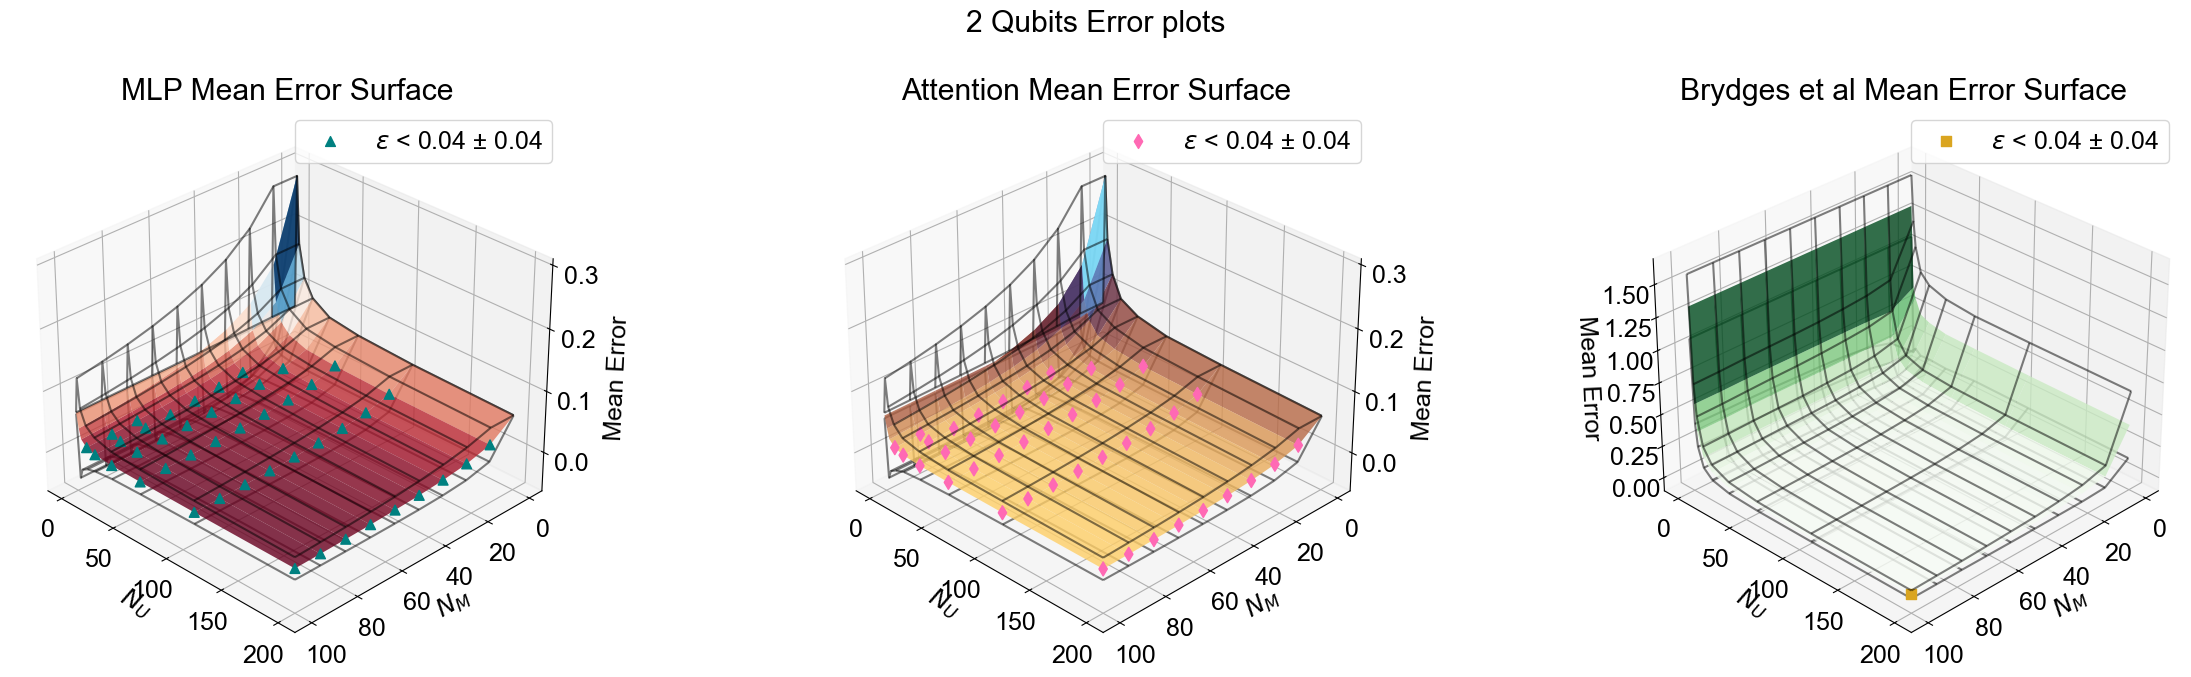

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(24, 7), dpi=dpi_num, subplot_kw={"projection": "3d"})

configs = [
    (mlp_all_loss_2q, "RdBu", colors["MLP"], "MLP", markers["MLP"]),
    (stella_all_loss_2q, "managua", colors["stella"], "Attention", markers["stella"]),
    (brydges_all_loss_2q, "Greens", colors["Brydges"], "Brydges et al", markers["Brydges"])
]

for ax, (this_dataframe, this_color, this_highlight, this_label, this_marker) in zip(axs.flatten(), configs):    
    plot_wireframe_and_3d(
        ax,
        shots=this_dataframe[:, 0],
        u_vals=this_dataframe[:, 1],
        mean_loss_surface=this_dataframe[:, 2],
        std_loss_surface=this_dataframe[:, 3],
        error_threshold= error_thresholds["2q"],
        unc_threshold= unc_threshold["2q"],
        label=this_label,
        color=this_color,
        highlight_color=this_highlight,
        wireframe_color="black",
        marker = this_marker
    )

ax.zaxis.set_ticks_position('upper')
ax.zaxis.set_label_position('upper')
    
plt.suptitle("2 Qubits Error plots")

plt.savefig(f"nunm_2heatmap_extrude.pdf", format="pdf", bbox_inches="tight")

plt.tight_layout()

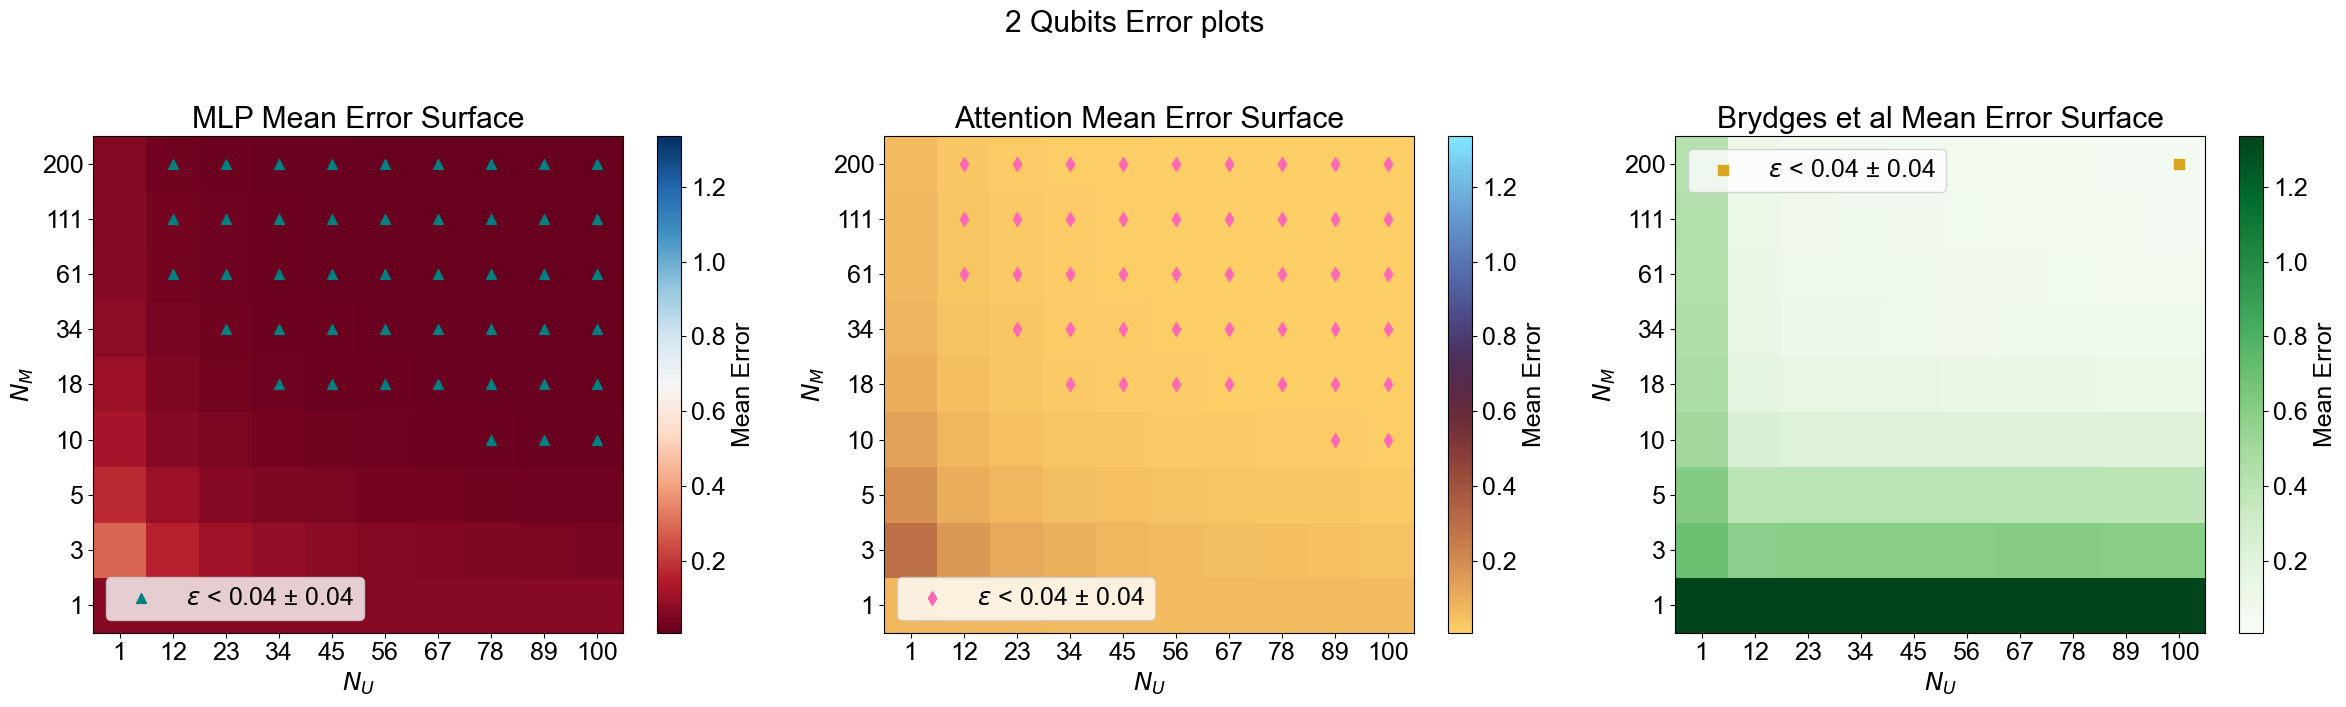

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(24, 7), dpi=dpi_num)

configs = [
    (mlp_all_loss_2q, "RdBu", colors["MLP"], "MLP", markers["MLP"]),
    (stella_all_loss_2q, "managua", colors["stella"], "Attention", markers["stella"]),
    (brydges_all_loss_2q, "Greens", colors["Brydges"], "Brydges et al", markers["Brydges"])
]

all_losses = np.concatenate([cfg[0][:, 2] for cfg in configs])
vmin, vmax = all_losses.min(), all_losses.max()

heatmaps = []

for ax, (this_dataframe, this_color, this_highlight, this_label, this_marker) in zip(axs.flatten(), configs):    
    hm = make_heatmap_optimal_points(
        ax,
        shots=this_dataframe[:, 0],
        u_vals=this_dataframe[:, 1],
        mean_loss_surface=this_dataframe[:, 2],
        std_loss_surface=this_dataframe[:, 3],
        error_threshold= error_thresholds["2q"],
        unc_threshold= unc_threshold["2q"],
        label=this_label,
        color=this_color,
        highlight_color=this_highlight,
        wireframe_color="black",
        marker = this_marker,
        vmax = vmax, vmin = vmin
    )
    heatmaps.append(hm)

plt.suptitle("2 Qubits Error plots", x = 0.48, y = 1.02)

plt.savefig(f"nunm_2heatmap.pdf", format="pdf", bbox_inches="tight")


plt.tight_layout()

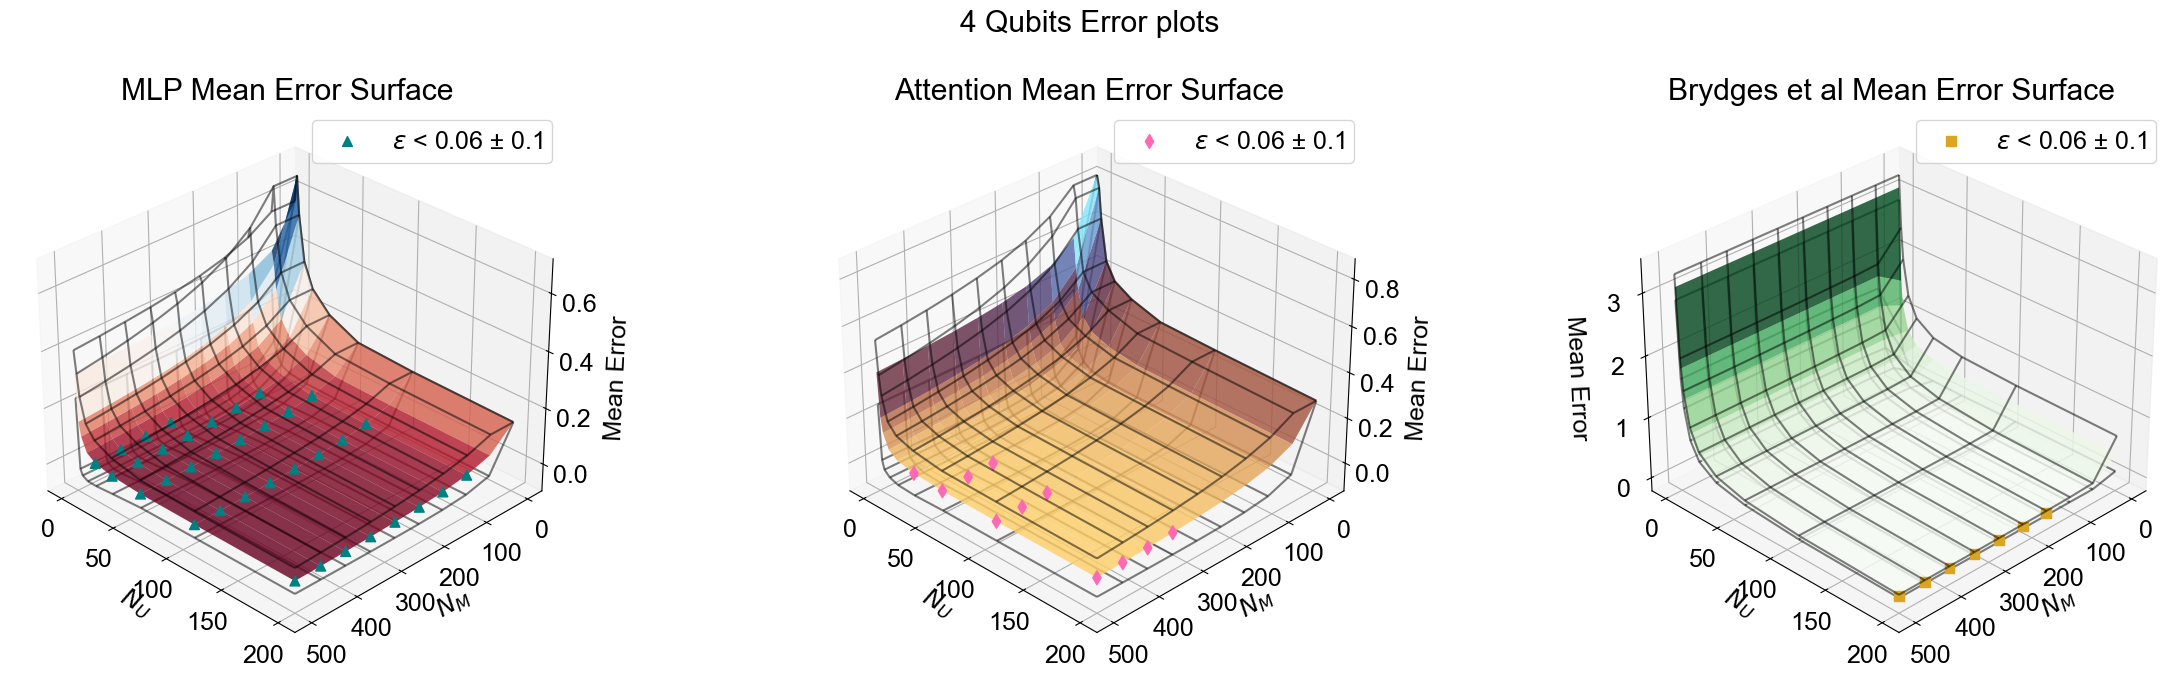

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(24, 7), dpi=dpi_num, subplot_kw={"projection": "3d"})

configs = [
    (mlp_all_loss_4q, "RdBu", colors["MLP"], "MLP", markers["MLP"]),
    (stella_all_loss_4q, "managua", colors["stella"], "Attention", markers["stella"]),
    (brydges_all_loss_4q, "Greens", colors["Brydges"], "Brydges et al", markers["Brydges"]),
]

for ax, (this_dataframe, this_color, this_highlight, this_label, this_marker) in zip(axs.flatten(), configs):    
    plot_wireframe_and_3d(
        ax,
        shots=this_dataframe[:, 0],
        u_vals=this_dataframe[:, 1],
        mean_loss_surface=this_dataframe[:, 2],
        std_loss_surface=this_dataframe[:, 3],
        error_threshold=error_thresholds["4q"],
        unc_threshold = unc_threshold["4q"],
        label=this_label,
        color=this_color,
        highlight_color=this_highlight,
        wireframe_color="black",
        marker = this_marker
    )

ax.zaxis.set_ticks_position('upper')
ax.zaxis.set_label_position('upper')

plt.suptitle("4 Qubits Error plots")

plt.savefig(f"nunm_4heatmap_extrude.pdf", format="pdf", bbox_inches="tight")


plt.tight_layout()

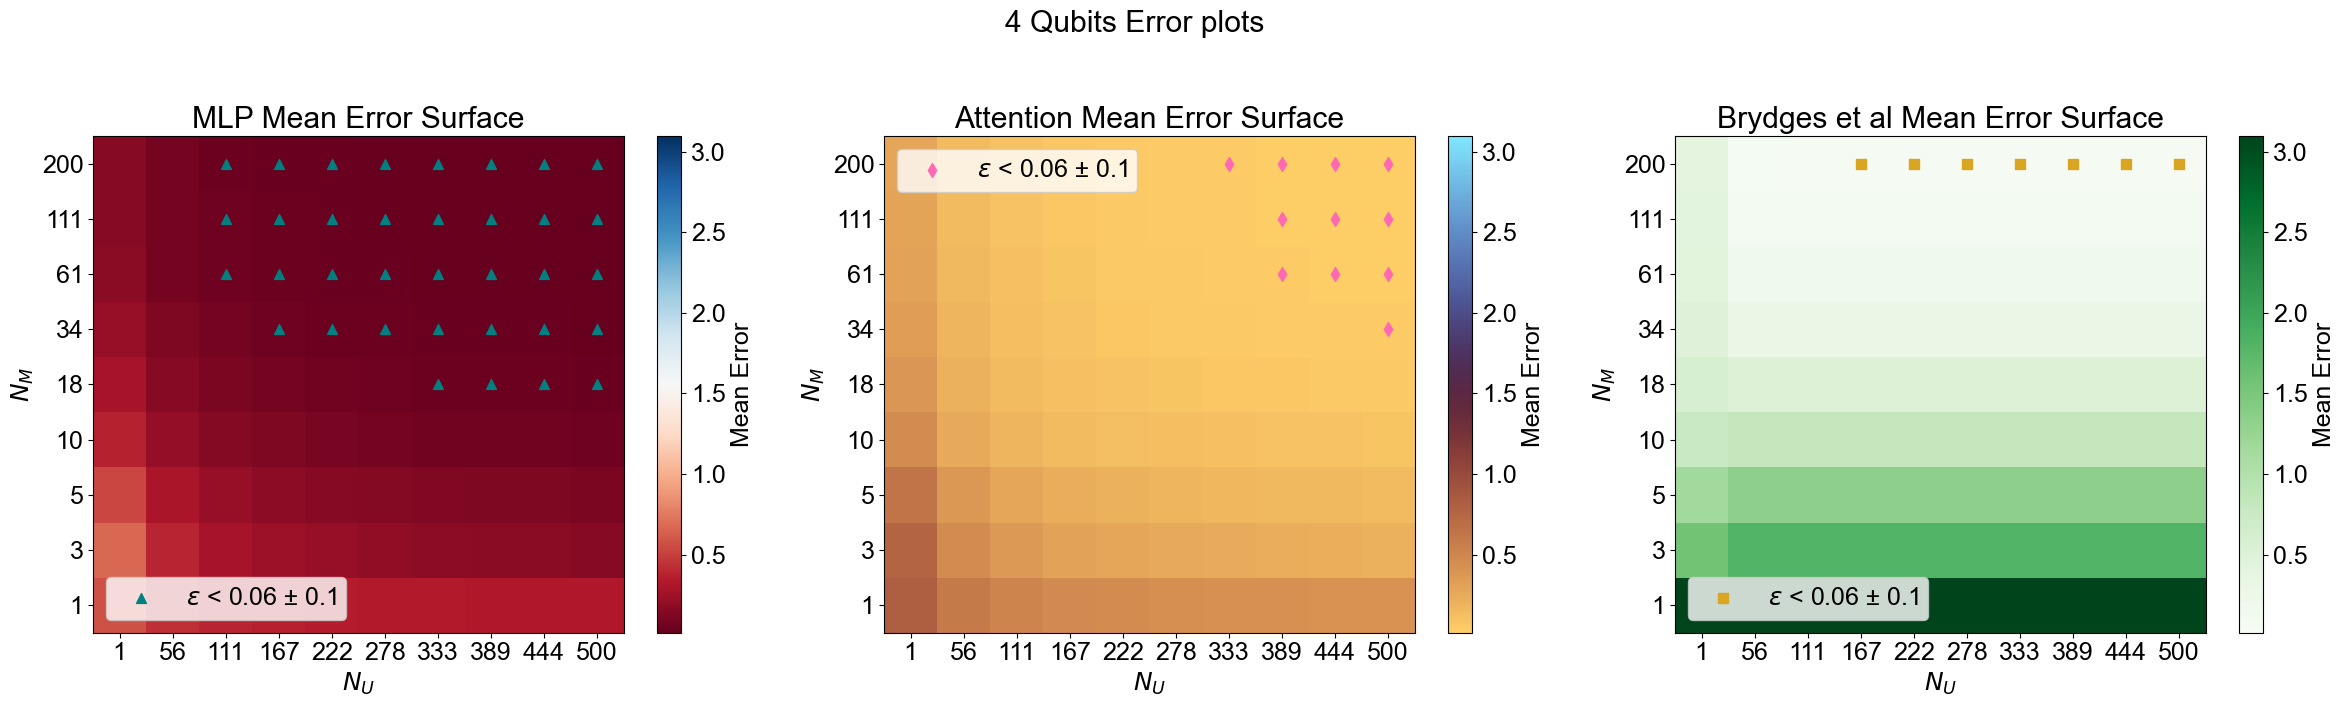

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(24, 7), dpi=dpi_num)

configs = [
    (mlp_all_loss_4q, "RdBu", colors["MLP"], "MLP", markers["MLP"]),
    (stella_all_loss_4q, "managua", colors["stella"], "Attention", markers["stella"]),
    (brydges_all_loss_4q, "Greens", colors["Brydges"], "Brydges et al", markers["Brydges"])
]

all_losses = np.concatenate([cfg[0][:, 2] for cfg in configs])
vmin, vmax = all_losses.min(), all_losses.max()

heatmaps = []

for ax, (this_dataframe, this_color, this_highlight, this_label, this_marker) in zip(axs.flatten(), configs):    
    hm = make_heatmap_optimal_points(
        ax,
        shots=this_dataframe[:, 0],
        u_vals=this_dataframe[:, 1],
        mean_loss_surface=this_dataframe[:, 2],
        std_loss_surface=this_dataframe[:, 3],
        good_idx=np.where((this_dataframe[:, 2] < error_thresholds["4q"]) & (this_dataframe[:, 3] < unc_threshold["4q"]))[0],
        error_threshold= error_thresholds["4q"],
        unc_threshold= unc_threshold["4q"],
        label=this_label,
        color=this_color,
        highlight_color=this_highlight,
        wireframe_color="black",
        marker = this_marker,
        vmin=vmin, vmax=vmax
    )
    heatmaps.append(hm)

plt.suptitle("4 Qubits Error plots", x=0.48, y=1.02)

plt.savefig(f"nunm_4heatmap.pdf", format="pdf", bbox_inches="tight")

plt.tight_layout()

In [16]:
def get_optimal_points(**kwargs):
    shots = np.array(kwargs["shots"])
    u_vals = np.array(kwargs["u_vals"])
    mean_loss = np.array(kwargs["mean_loss_surface"])
    std_loss = np.array(kwargs["std_loss_surface"])
    
    # Remove duplicates based on (shots, u_vals)
    _, unique_idx = np.unique(np.column_stack((shots, u_vals)), axis=0, return_index=True)
    shots = shots[unique_idx]
    u_vals = u_vals[unique_idx]
    mean_loss = mean_loss[unique_idx]
    std_loss = std_loss[unique_idx]
    
    # Find indices that satisfy thresholds
    good_idx = np.where((mean_loss < kwargs["error_threshold"]) & (std_loss < kwargs["unc_threshold"]))[0]
    
    if len(good_idx) == 0:
        return None  # or np.nan, if no points satisfy the condition
    
    # Compute product for the good indices
    optimal_values = shots[good_idx] * u_vals[good_idx]
    
    return optimal_values.min()

In [17]:
brydges_points = []
stella_points = []
mlp_points = []

call_names = ["2q", "4q"]

for i, this_dataframe in enumerate([mlp_all_loss_2q, mlp_all_loss_4q]):
    min_points = get_optimal_points(shots=this_dataframe[:, 0], u_vals=this_dataframe[:, 1],
                                    mean_loss_surface=this_dataframe[:, 2], std_loss_surface=this_dataframe[:, 3],
                                    error_threshold= error_thresholds[call_names[i]], unc_threshold= unc_threshold[call_names[i]],)
    
    mlp_points.append(min_points)

for i, this_dataframe in enumerate([stella_all_loss_2q, stella_all_loss_4q]):
    min_points = get_optimal_points(shots=this_dataframe[:, 0], u_vals=this_dataframe[:, 1],
                                    mean_loss_surface=this_dataframe[:, 2], std_loss_surface=this_dataframe[:, 3],
                                    error_threshold= error_thresholds[call_names[i]], unc_threshold= unc_threshold[call_names[i]],)
    
    stella_points.append(min_points)

for i, this_dataframe in enumerate([brydges_all_loss_2q, brydges_all_loss_4q]):
    min_points = get_optimal_points(shots=this_dataframe[:, 0], u_vals=this_dataframe[:, 1],
                                    mean_loss_surface=this_dataframe[:, 2], std_loss_surface=this_dataframe[:, 3],
                                    error_threshold= error_thresholds[call_names[i]], unc_threshold= unc_threshold[call_names[i]],)
    
    brydges_points.append(min_points)


all_points = np.stack([brydges_points, stella_points, mlp_points])

points_2q = all_points[:, 0]
points_4q = all_points[:, 1]

In [18]:
print("Percentage differences from Brydges (relative):")

print("\nFor 2 qubits:")
print("Attention vs Brydges et al: {:.2f}%".format(abs(100 * (stella_points[0] - brydges_points[0]) / brydges_points[0])))
print("MLP vs Brydges et al: {:.2f}%".format(abs(100 * (mlp_points[0] - brydges_points[0]) / brydges_points[0])))

print("\nFor 4 qubits:")
print("Attention vs Brydges et al: {:.2f}%".format(abs(100 * (stella_points[1] - brydges_points[1]) / brydges_points[1])))
print("MLP vs Brydges et al: {:.2f}%".format(abs(100 * (mlp_points[1] - brydges_points[1]) / brydges_points[1])))

Percentage differences from Brydges (relative):

For 2 qubits:
Attention vs Brydges et al: 96.94%
MLP vs Brydges et al: 96.94%

For 4 qubits:
Attention vs Brydges et al: 49.10%
MLP vs Brydges et al: 83.00%


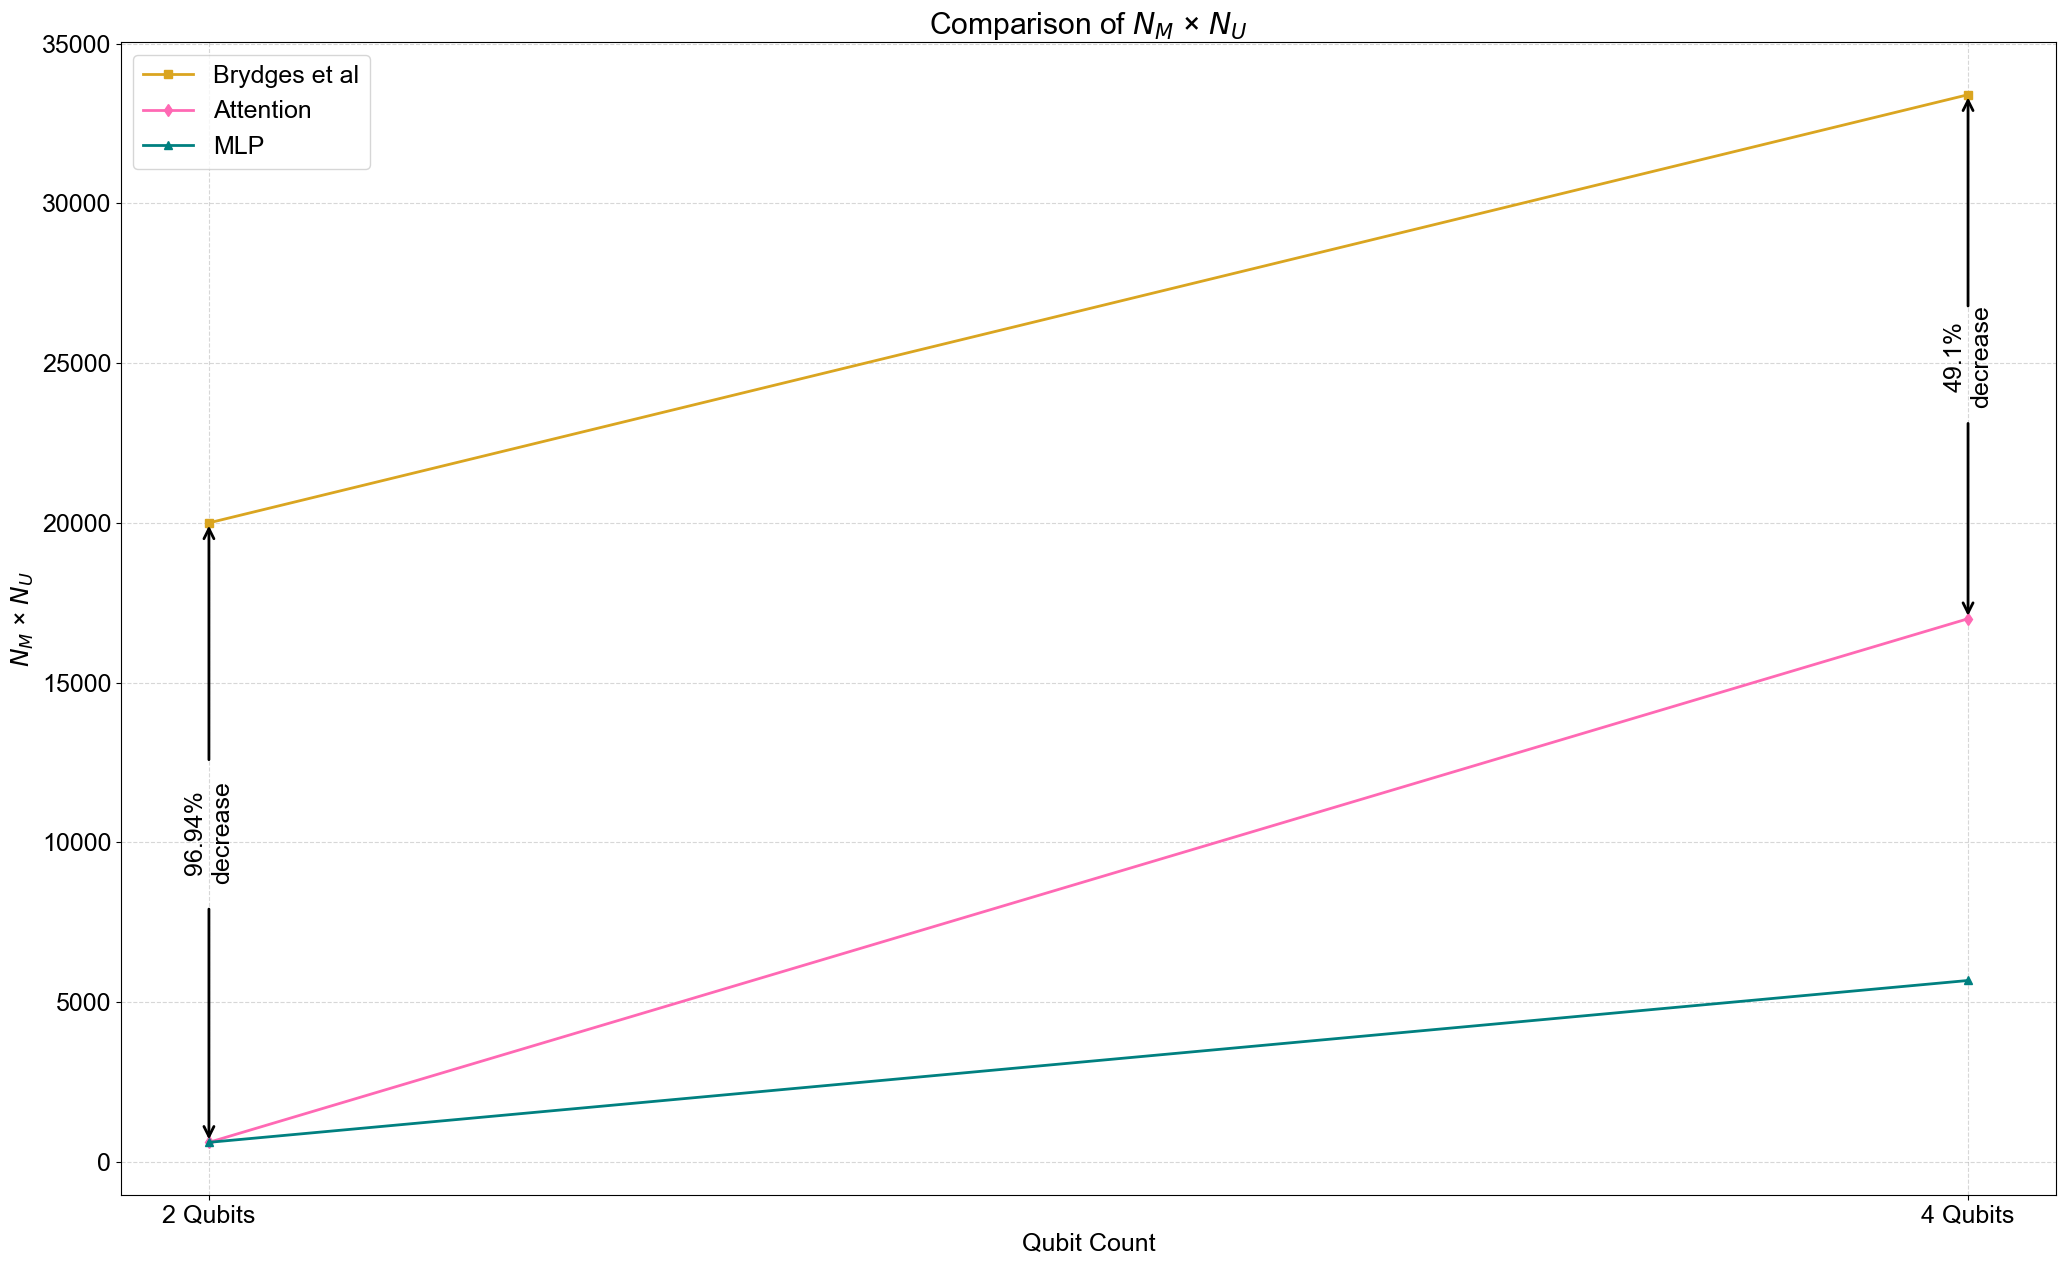

In [20]:
# Model names
models = ["Brydges et al", "Attention", "MLP"]
model_label = ["Brydges", "stella", "MLP"]

# Products for 2q and 4q
points_2q = all_points[:, 0]
points_4q = all_points[:, 1]

# Qubit labels for x-axis
qubits = ["2 Qubits", "4 Qubits"]

fig, ax = plt.subplots(1, 1, figsize=(21, 13), dpi=dpi_num)

# Plot line + scatter for each model
for i, model in enumerate(models):
    y_values = [points_2q[i], points_4q[i]]
    ax.plot(qubits, y_values, marker=markers[model_label[i]], label=model, linewidth=2, color = colors[model_label[i]])

y1 = max(points_2q)  # Value before improvement
y2 = min(points_2q)   # Value after improvement

x_point = 0
mid_y = (y1 + y2) / 2

# Add annotation text
plt.text(x_point, mid_y, f"{np.round(((y1-y2)/y1)*100, 2)}%\ndecrease", color='black', ha='center', va='center', rotation = 90)

# Add an arrow showing the improvement
plt.annotate("", xy=(x_point, y1), xytext=(x_point, y1/2 + 2500), arrowprops=dict(arrowstyle="->", color='black', lw=2))
plt.annotate("", xy=(x_point, y1/2 - 2000), xytext=(x_point, y2), arrowprops=dict(arrowstyle="<-", color='black', lw=2))

sort_4q = sorted(points_4q)

y1 = sort_4q[-1]  # Value before improvement
y2 = sort_4q[-2]   # Value after improvement

x_point = 1
mid_y = (y1 + y2) / 2

# Add annotation text
plt.text(x_point, mid_y, f"{np.round(((y1-y2)/y1)*100, 2)}%\ndecrease", color='black', ha='center', va='center', rotation = 90)

# Add an arrow showing the improvement
plt.annotate("", xy=(x_point, y1), xytext=(x_point, y1/2 + 10000), arrowprops=dict(arrowstyle="->", color='black', lw=2))
plt.annotate("", xy=(x_point, y1/2 + 6500), xytext=(x_point, y2), arrowprops=dict(arrowstyle="<-", color='black', lw=2))

# Add labels and title
ax.set_ylabel(rf"$N_M$ × $N_U$")
ax.set_xlabel("Qubit Count")
ax.set_title(rf"Comparison of $N_M$ × $N_U$")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()